# 01 — Baseline L1 gap

Loads `comparison_synthetic.csv` (+ `comparison_b0039.csv` if present),
builds the headline table per the spec, and plots per-case L1 deviation
by method.

**Strict-feasibility rule:** rows with `feasible=False` are EXCLUDED
from the L1 ranking. No averaging over infeasible solutions.


In [1]:
from pathlib import Path
import pandas as pd

# Notebook lives in research/strict_feasibility_2d/analysis/
# CSVs live in ../runners/output/
_HERE = Path.cwd()
OUTDIR = _HERE.parent / 'runners' / 'output' if (_HERE.name == 'analysis') else _HERE
# Fallback: locate by searching from HERE upward.
if not (OUTDIR / 'comparison_synthetic.csv').exists():
    for parent in [_HERE, *_HERE.parents]:
        cand = parent / 'research' / 'strict_feasibility_2d' / 'runners' / 'output'
        if (cand / 'comparison_synthetic.csv').exists():
            OUTDIR = cand
            break

print('CSV directory:', OUTDIR)
df_synth = pd.read_csv(OUTDIR / 'comparison_synthetic.csv')
df_b0039 = pd.read_csv(OUTDIR / 'comparison_b0039.csv') if (OUTDIR / 'comparison_b0039.csv').exists() else pd.DataFrame()
df = pd.concat([df_synth, df_b0039], ignore_index=True)
print(f'Loaded {len(df)} rows across {df.case_id.nunique()} cases and {df.method.nunique()} methods.')
df.head()


CSV directory: C:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\research\strict_feasibility_2d\runners\output
Loaded 94 rows across 10 cases and 10 methods.


,case_id,method,shape,init_n_neg_2tri,init_min_T,final_n_neg_2tri,final_min_T,feasible,L1_dev,L2_dev,Linf_dev,wall_s,error
0,01a_10x10_crossing,harmonic_only,10x10,16,-0.743932,0,0.147658,True,24.912511,5.756970,3.106366,0.004641,NaN
1,01a_10x10_crossing,m10,10x10,16,-0.743932,0,0.042751,True,8.396565,3.402374,2.269539,0.060180,NaN
2,01a_10x10_crossing,m14,10x10,16,-0.743932,0,0.011000,True,6.676494,3.052932,2.105146,0.141522,NaN
3,01a_10x10_crossing,m14_schwarz,10x10,16,-0.743932,0,0.011000,True,6.676494,3.052932,2.105146,0.141366,NaN
4,01a_10x10_crossing,cluster_pipeline,10x10,16,-0.743932,16,-0.743932,False,0.000000,0.000000,0.000000,0.000010,NotImplementedError: cluster_pipeline adapter ...


In [2]:
# Per-method feasibility summary.
summary = df.groupby('method').agg(
    n_runs=('feasible', 'size'),
    n_feasible=('feasible', 'sum'),
).assign(
    feasible_frac=lambda d: d['n_feasible'] / d['n_runs'],
)
summary.sort_values('feasible_frac', ascending=False)


,n_runs,n_feasible,feasible_frac
method,,,
cluster_slp,10,10,1.000000
m14,10,10,1.000000
slp_iter_m14_seed,9,9,1.000000
m10,9,9,1.000000
slp_iter,10,10,1.000000
m14_schwarz,9,9,1.000000
slp_iter_wide_tr,9,9,1.000000
lp_oneshot,9,3,0.333333
harmonic_only,10,3,0.300000


In [3]:
# Headline table: L1 deviation per case x method (feasible-only).
df_feas = df[df['feasible']].copy()
pivot_L1 = df_feas.pivot_table(
    index='case_id', columns='method', values='L1_dev', aggfunc='first',
).round(4)

# Add an `L1_lp_oneshot` baseline column and the per-method gap vs m14.
if 'lp_oneshot' in pivot_L1.columns and 'm14' in pivot_L1.columns:
    pivot_L1['_gap_m14_minus_lp'] = pivot_L1['m14'] - pivot_L1['lp_oneshot']
pivot_L1


method,cluster_slp,harmonic_only,lp_oneshot,m10,m14,m14_schwarz,slp_iter,slp_iter_m14_seed,slp_iter_wide_tr,_gap_m14_minus_lp
case_id,,,,,,,,,,
01a_10x10_crossing,6.6403,24.9125,6.6403,8.3966,6.6765,6.6765,6.6403,6.6403,6.6403,0.0362
01b_10x10_opposite,3.5523,NaN,3.5362,14.1507,3.5524,3.5523,3.5362,3.5362,3.5362,0.0162
03a_10x10_opposite,7.1372,NaN,NaN,24.8102,7.1351,7.1352,7.0927,7.0927,7.0927,NaN
03b_10x10_crossing,15.8673,NaN,NaN,52.4446,15.8675,15.8675,26.1528,15.8190,38.5861,NaN
03c_20x20_opposite,22.9905,NaN,NaN,157.1760,22.9905,22.9906,22.8717,22.8716,22.8717,NaN
03d_20x20_crossing,45.1037,NaN,NaN,262.1905,43.7644,43.7630,111.3726,43.6595,166.7369,NaN
b0039_z012,175637.8190,NaN,NaN,NaN,184033.9048,NaN,287316.3115,NaN,NaN,NaN
bowtie_7x7_shoelace,1.4200,2.4000,1.4200,2.4000,1.4663,1.4663,1.4200,1.4200,1.4200,0.0463
dense_bowtie_cluster_15x15,12.7800,21.6000,NaN,14.3723,12.9583,12.9583,12.7800,12.7800,12.7800,NaN


In [4]:
# Wall-time table.
pivot_wall = df.pivot_table(
    index='case_id', columns='method', values='wall_s', aggfunc='first',
).round(2)
pivot_wall


method,cluster_pipeline,cluster_slp,harmonic_only,lp_oneshot,m10,m14,m14_schwarz,slp_iter,slp_iter_m14_seed,slp_iter_wide_tr
case_id,,,,,,,,,,
01a_10x10_crossing,0.0,0.15,0.00,0.06,0.06,0.14,0.14,0.08,0.16,0.08
01b_10x10_opposite,0.0,0.65,0.01,0.07,0.06,0.14,0.16,0.09,0.17,0.08
03a_10x10_opposite,0.0,1.48,0.01,0.17,0.17,0.31,0.39,0.21,0.33,0.22
03b_10x10_crossing,0.0,2.05,0.00,0.22,0.23,0.39,0.41,0.32,0.43,0.33
03c_20x20_opposite,0.0,3.58,0.02,0.41,0.29,0.52,0.92,0.39,0.66,0.43
03d_20x20_crossing,0.0,4.44,0.02,0.28,0.26,0.48,0.87,0.53,0.59,0.54
b0039_z012,NaN,63.71,0.87,NaN,NaN,267.06,NaN,515.28,NaN,NaN
bowtie_7x7_shoelace,0.0,0.04,0.00,0.01,0.00,0.02,0.02,0.02,0.05,0.09
dense_bowtie_cluster_15x15,0.0,0.18,0.00,0.01,0.00,0.06,0.06,0.25,0.26,0.20


## Reading the headline table

* A blank cell means that (case, method) was infeasible at exact eval
  and excluded — see the feasibility summary cell above for which
  method failed where.
* `_gap_m14_minus_lp` = `L1_dev(m14) - L1_dev(lp_oneshot)` — positive
  numbers mean LP wins on L1, negative means M14 wins.
* `cluster_pipeline` rows are expected to be empty / errored — the
  adapter is not wired yet (see Task 9 note in the plan).


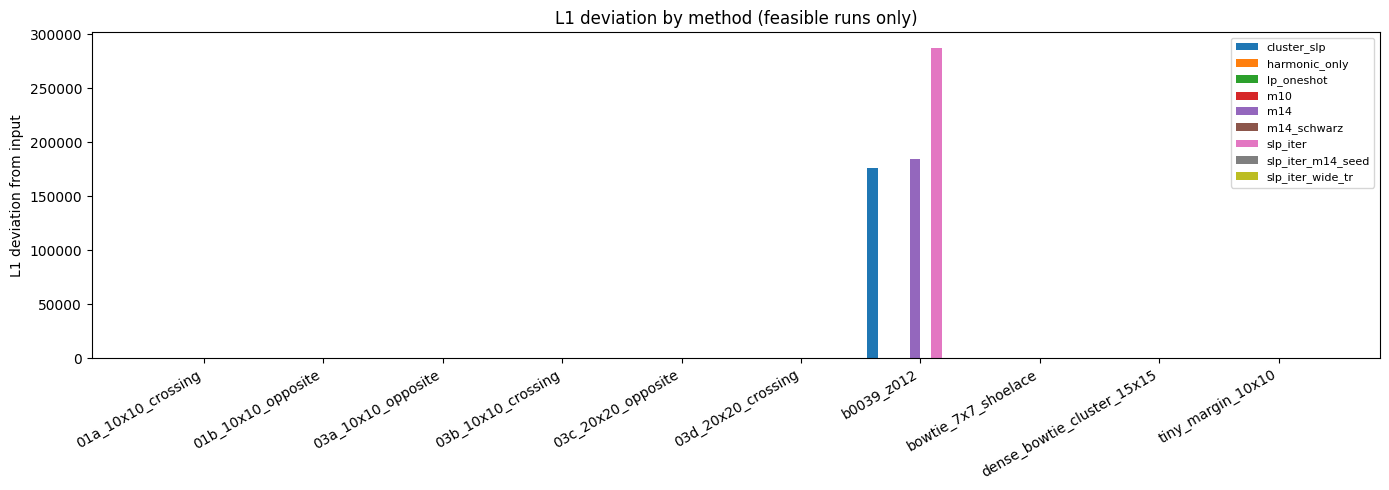

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Per-case bar chart. Drop the gap column for plotting.
cases = pivot_L1.index.tolist()
methods = [m for m in pivot_L1.columns if not m.startswith('_')]
if cases and methods:
    fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(cases)), 5))
    n = len(methods)
    x = np.arange(len(cases))
    w = 0.8 / n
    for i, m in enumerate(methods):
        vals = pivot_L1[m].values
        ax.bar(x + (i - n / 2) * w, vals, width=w, label=m)
    ax.set_xticks(x)
    ax.set_xticklabels(cases, rotation=30, ha='right')
    ax.set_ylabel('L1 deviation from input')
    ax.set_title('L1 deviation by method (feasible runs only)')
    ax.legend(loc='upper right', fontsize=8)
    fig.tight_layout()
    fig.savefig(_HERE / 'l1_per_case.png' if _HERE.name == 'analysis' else 'l1_per_case.png', dpi=150)
    plt.show()
else:
    print('No feasible rows to plot.')
